Step 1: Loading required data chunks...
Step 2: Filtering RCA data (Optimized)...


Processing chunks:  54%|█████▎    | 15/28 [00:04<00:04,  3.02it/s]


Step 3: Calculating persistence scores (Vectorized)...

BENCHMARK: AUC=0.6524, P@50=0.1600, R@50=0.0004


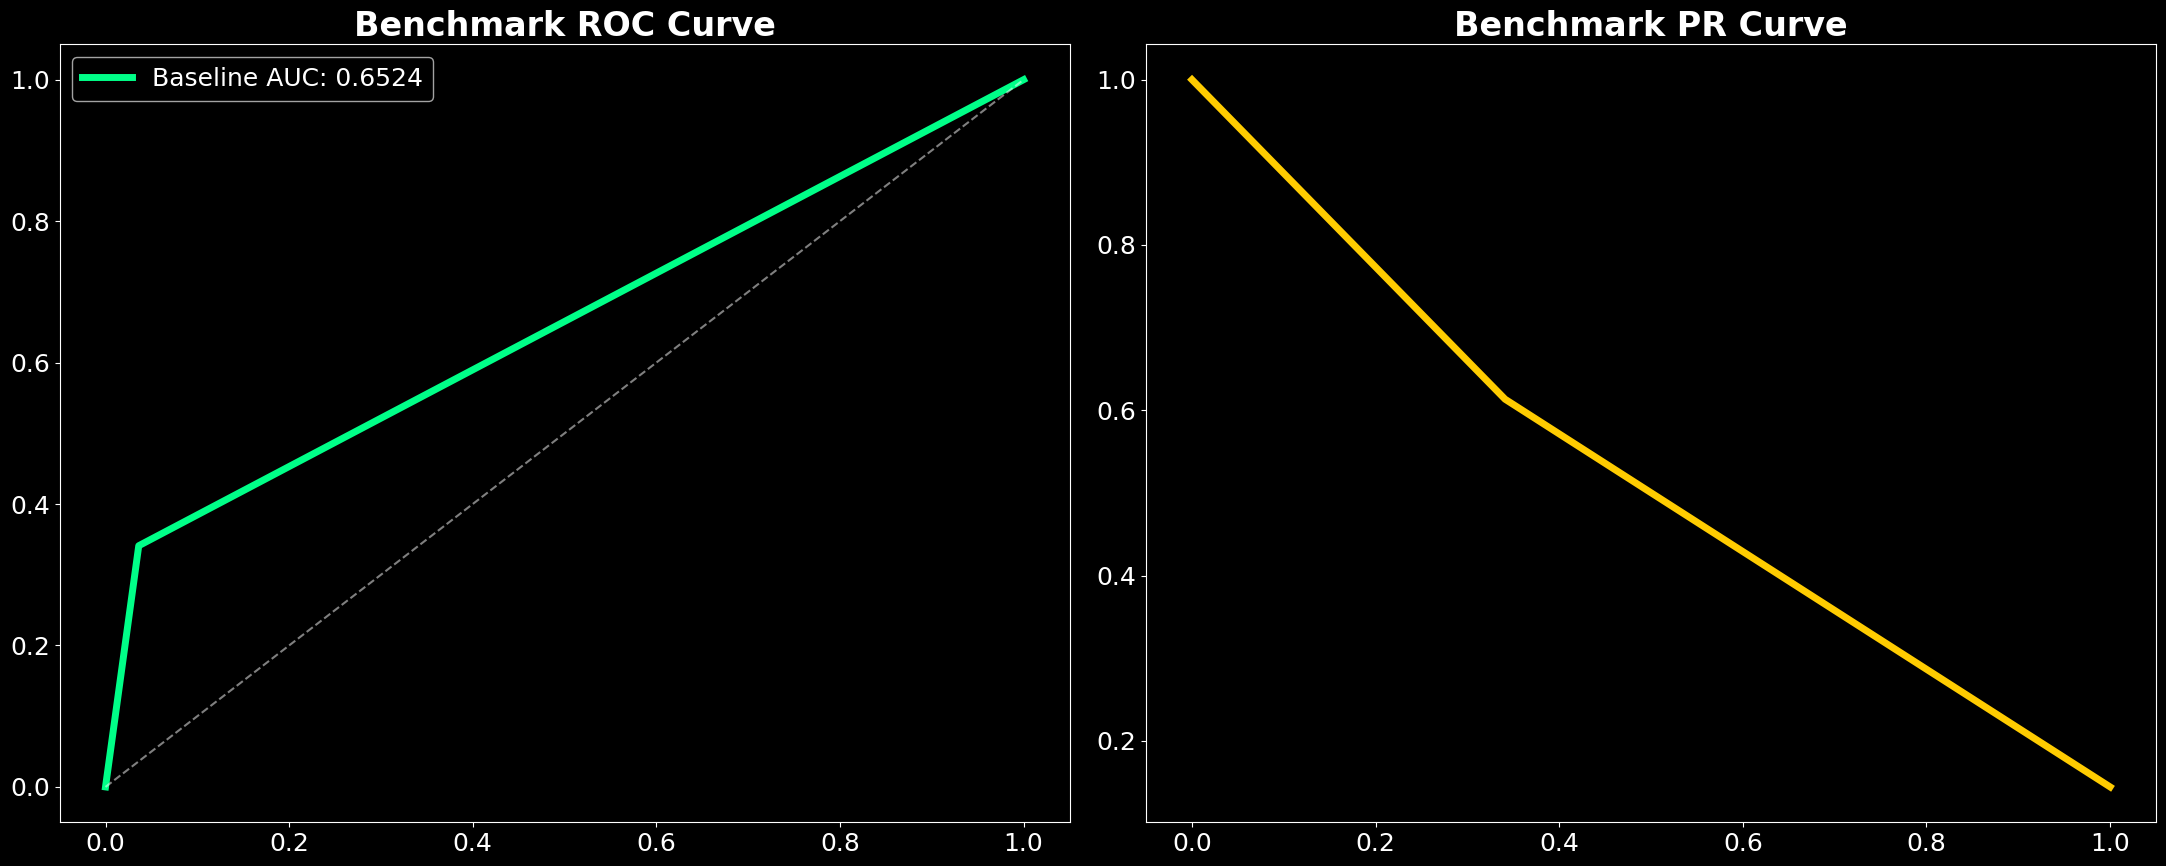

Optimal F1-Score: 0.4383 (at threshold 0.3333)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, roc_curve, auc
from tqdm import tqdm

def run_benchamrk_lightning_fast():
    print("Step 1: Loading required data chunks...")
    test_labels = pd.read_csv('data/GNNModelTraining/test_labels.csv')
    relevant_pairs = test_labels[['country', 'product']].drop_duplicates()
    
    # Fast filtering of the huge RCA file
    print("Step 2: Filtering RCA data (Optimized)...")
    chunk_iterator = pd.read_csv('data/rca_cpt.csv', chunksize=1000000)
    filtered_list = []
    for chunk in tqdm(chunk_iterator, total=28, desc="Processing chunks"):
        filtered_list.append(chunk.merge(relevant_pairs, on=['country', 'product']))
    
    rca_filtered = pd.concat(filtered_list)

    print("Step 3: Calculating persistence scores (Vectorized)...")
    # Pivot to wide format (Years as columns)
    rca_wide = rca_filtered.pivot_table(
        index=['country', 'product'], 
        columns='year', 
        values='rca', 
        fill_value=0
    )
    
    # Join labels with their history
    test_bench = test_labels.merge(rca_wide, on=['country', 'product'], how='left').fillna(0)
    
    # Compute the average of [t, t-1, t-2] for every row at once
    # We do a loop only over the unique years (usually just 1 or 2 years)
    for eval_year in test_bench['year'].unique():
        mask = (test_bench['year'] == eval_year)
        # Check RCA >= 1 for the 3 current/previous years
        cols = [eval_year, eval_year-1, eval_year-2]
        valid_cols = [c for c in cols if c in test_bench.columns]
        
        if valid_cols:
            test_bench.loc[mask, 'score'] = (test_bench.loc[mask, valid_cols] >= 1).mean(axis=1)
        else:
            test_bench.loc[mask, 'score'] = 0

    y_true = test_labels['label'].values
    y_score = test_bench['score'].values

    # 4. Final Evaluation Logic
    auc_val = roc_auc_score(y_true, y_score)
    top_k_idx = np.argsort(y_score)[::-1][:50]
    p50 = y_true[top_k_idx].mean()
    r50 = y_true[top_k_idx].sum() / y_true.sum()
    
    print("\n" + "="*30)
    print(f"BENCHMARK: AUC={auc_val:.4f}, P@50={p50:.4f}, R@50={r50:.4f}")
    print("="*30)

    # Plotting code (using high visibility fonts)
    plt.style.use('dark_background')
    plt.rcParams.update({'font.size': 18})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
    
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax1.plot(fpr, tpr, color='#00ff88', lw=5, label=f'Baseline AUC: {auc_val:.4f}')
    ax1.plot([0,1], [0,1], 'w--', alpha=0.5)
    ax1.set_title("Benchmark ROC Curve", fontweight='bold', fontsize=24)
    ax1.legend()

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ax2.plot(rec, prec, color='#ffcc00', lw=5)
    ax2.set_title("Benchmark PR Curve", fontweight='bold', fontsize=24)
    plt.tight_layout()
    plt.show()

    # 1. Calculate the precision-recall curve to find the best threshold
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    # 2. Calculate F1 for every threshold and pick the maximum
    # (Adding a small epsilon to avoid division by zero)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_f1 = np.max(f1_scores)
    best_f1_threshold = thresholds[np.argmax(f1_scores)]

    print(f"Optimal F1-Score: {best_f1:.4f} (at threshold {best_f1_threshold:.4f})")


# Run the new optimized version
run_benchamrk_lightning_fast()


In [8]:
from sklearn.metrics import f1_score

# 1. Calculate the precision-recall curve to find the best threshold
precision, recall, thresholds = precision_recall_curve(y_true, y_score)

# 2. Calculate F1 for every threshold and pick the maximum
# (Adding a small epsilon to avoid division by zero)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1 = np.max(f1_scores)
best_f1_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal F1-Score: {best_f1:.4f} (at threshold {best_f1_threshold:.4f})")


NameError: name 'y_true' is not defined